In [ ]:
import os

# counting the number of files in traind folder
path, dirs,files = next(os.walk('train'))
file_count = len(files)
print('Number of images : ', file_count)

Printing the name of images

In [ ]:
file_name = os.listdir('train')
print(file_name)

Importing the Dependencies

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

Diplaying the Images of dogs and cats

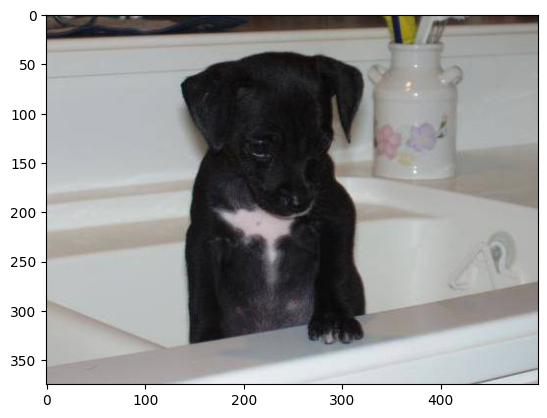

In [4]:
# display dog image
img = mpimg.imread('train/dog.8298.jpg')
plt.imshow(img)

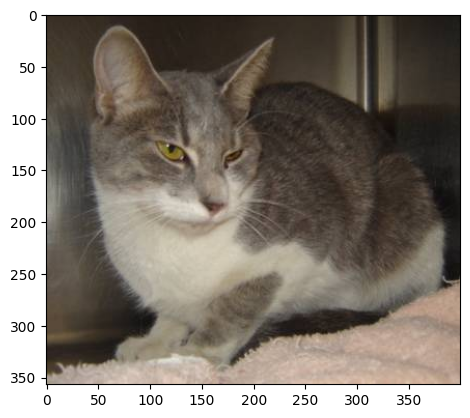

In [5]:
# display cat image
img = mpimg.imread('train/cat.4352.jpg')
plt.imshow(img)

In [27]:
dogs = 0
cats = 0

for image in file_name:
    if image[0:3] == "dog":
        dogs +=1
    else:
        cats += 1

print("Dogs: ", dogs)
print("Cats: ", cats)

Dogs:  0
Cats:  13


Resizing all the images

In [ ]:
# creating a directory for resized image 
os.mkdir('trained_resized_1')

In [ ]:
original_folder = 'train/'
resized_folder = 'trained_resized_1/'

for i in range(12500):
    
    filename = os.listdir(original_folder)[i]
    img_path = original_folder  + filename

    img = Image.open(img_path)
    img = img.resize((224, 224))
    img = img.convert('RGB')

    new_Img_path = resized_folder + filename
    img.save(new_Img_path)

In [32]:
os.mkdir('trained_resized_2')

In [ ]:
original_folder = 'train/'
resized_folder = 'trained_resized_2/'

for i in range(25000):
    
    if i >= 12500:
        filename = os.listdir(original_folder)[i]
        img_path = original_folder  + filename

        img = Image.open(img_path)
        img = img.resize((224, 224))
        img = img.convert('RGB')

        new_Img_path = resized_folder + filename
        img.save(new_Img_path)

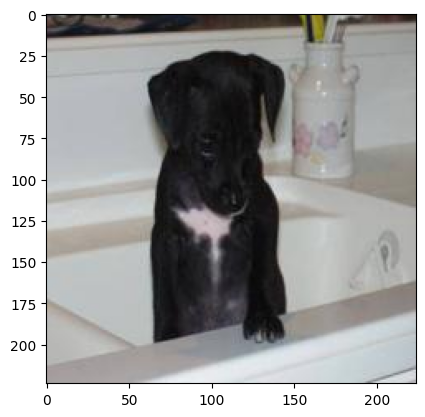

In [39]:
# display dog image
img = mpimg.imread('trained_resized_1/dog.8298.jpg')
plt.imshow(img)

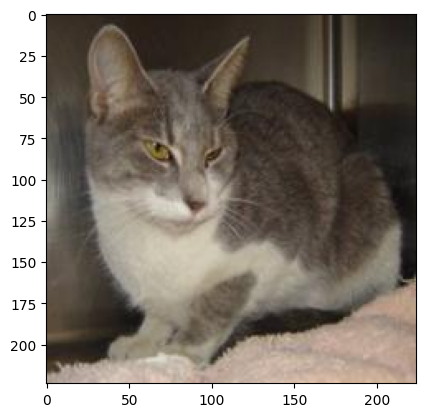

In [40]:
# display cat image
img = mpimg.imread('trained_resized_1/cat.4352.jpg')
plt.imshow(img)

Creating Labels for Resized image of dogs and cats

Cat --> 0

Dog --> 1

In [41]:
# creating for loop to assign labels

filenames= os.listdir('trained_resized_1')


labels = []

for i in range(12500):

    file_name = filenames[i]
    label = file_name[0:3]

    if label == 'dog':
        labels.append(1)

    else:
        labels.append(0)

Converting all the resized images as numpy arrays

In [13]:
import cv2
import glob

In [45]:
image_directory = 'trained_resized_1/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [46]:
print(dog_cat_images.shape)

(12500, 224, 224, 3)


In [49]:
x = dog_cat_images
y = np.asarray(labels)

Train Test Split

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [51]:
print(x.shape, x_train.shape, x_test.shape)

(12500, 224, 224, 3) (10000, 224, 224, 3) (2500, 224, 224, 3)


20,000 --> training images

5,000  --> test images

In [52]:
# scaling the data
x_train_scaled = x_train / 255

x_test_scaled = x_test / 255

Building the Neural Network

In [54]:
import tensorflow as tf
import tensorflow_hub as hub

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

pretrained_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

pretrained_model.trainable = False

In [57]:
number_of_classes = 2

model = tf.keras.Sequential([

    pretrained_model,
    GlobalAveragePooling2D(),
    tf.keras.layers.Dense(number_of_classes)

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [59]:
model.fit(x_train_scaled, y_train, epochs=5)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 399ms/step - acc: 0.9680 - loss: 0.0879
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 116s 371ms/step - acc: 0.9803 - loss: 0.0544
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 119s 381ms/step - acc: 0.9829 - loss: 0.0473
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 117s 373ms/step - acc: 0.9847 - loss: 0.0426
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 117s 373ms/step - acc: 0.9868 - loss: 0.0382


In [60]:
score, acc = model.evaluate(x_test_scaled, y_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 387ms/step - acc: 0.9748 - loss: 0.0710


Saving Trained Model

In [67]:
model.save("cats_dogs_model.keras")